# Análisis de Fenotipos — K-Means Clustering

**Objetivo:** Segmentar la población del dataset CDC BRFSS 2015 en grupos homogéneos (fenotipos)
usando K-Means sin utilizar la etiqueta de diabetes. Esto permite identificar perfiles de riesgo
de manera no supervisada y analizar si los fenotipos encontrados capturan diferencias clínicas reales.

**Ítem de rúbrica:** I4 — K-Means con `k-means++`, método del codo y coeficiente de silueta.

---

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

sys.path.insert(0, str(Path.cwd().parent))

from entrenamiento.fenotipado import FenotipadoKMeans
from config import COLUMNAS_CDC, RUTA_DATASET_PROCESADO, REPORTES_DIR, SEMILLA_ALEATORIA

warnings.filterwarnings('ignore')
%matplotlib inline

# ── parámetros ajustables ──────────────────────────────────────────────────────
K_MIN = 2        # k mínimo a evaluar
K_MAX = 10       # k máximo a evaluar
N_MUESTRA_K = 5000  # registros para la búsqueda de k (más rápido que usar 50k)
SEMILLA = SEMILLA_ALEATORIA
# ──────────────────────────────────────────────────────────────────────────────

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'sans-serif',
})
COLOR_RIESGO = '#C62828'
COLOR_SEGURO = '#006847'
COLOR_NEUTRO = '#B0BEC5'
COLOR_ALERTA = '#F9A825'

In [2]:
# ── Carga del dataset procesado ───────────────────────────────────────────────
df = pd.read_parquet(RUTA_DATASET_PROCESADO)

X = df[list(COLUMNAS_CDC)].copy()
y = df['Diabetes_binary'].copy() if 'Diabetes_binary' in df.columns else None

n_total      = len(X)
n_diabetes   = int(y.sum()) if y is not None else 0
pct_diabetes = y.mean() if y is not None else 0.0

display(Markdown(f"""
### Datos cargados

| Atributo | Valor |
|---|---|
| Registros totales | {n_total:,} |
| Variables predictoras | {len(COLUMNAS_CDC)} |
| Diabéticos (clase 1) | {n_diabetes:,} ({pct_diabetes:.1%}) |
| No diabéticos (clase 0) | {n_total - n_diabetes:,} ({1 - pct_diabetes:.1%}) |
| Dataset fuente | `{RUTA_DATASET_PROCESADO.name}` |

> El análisis K-Means se realiza **sin usar la etiqueta de diabetes** (`Diabetes_binary`).
> La etiqueta se utiliza únicamente en el Bloque 4 para validar si los fenotipos
> encontrados capturan diferencias clínicas reales.
"""))


### Datos cargados

| Atributo | Valor |
|---|---|
| Registros totales | 50,000 |
| Variables predictoras | 21 |
| Diabéticos (clase 1) | 6,967 (13.9%) |
| No diabéticos (clase 0) | 43,033 (86.1%) |
| Dataset fuente | `dataset_procesado.parquet` |

> El análisis K-Means se realiza **sin usar la etiqueta de diabetes** (`Diabetes_binary`).
> La etiqueta se utiliza únicamente en el Bloque 4 para validar si los fenotipos
> encontrados capturan diferencias clínicas reales.


---

## Bloque 1 — Selección del número óptimo de clústeres

**Objetivo:** Encontrar el k que mejor equilibra cohesión interna y separación entre grupos.
Se usan dos criterios complementarios:

- **Método del codo** — grafica la inercia (suma de cuadrados intra-clúster) vs k. El codo
  visual indica dónde agregar más clusters deja de aportar.
- **Coeficiente de silueta** — mide, para cada punto, qué tan parecido es a su propio
  cluster vs el cluster más cercano. Valores entre 0 y 1; más alto es mejor.

In [3]:
# ── Búsqueda de k óptimo sobre una muestra representativa ────────────────────
rng = np.random.RandomState(SEMILLA)
idx_muestra = rng.choice(len(X), size=min(N_MUESTRA_K, len(X)), replace=False)
X_muestra = X.iloc[idx_muestra]

ks = list(range(K_MIN, K_MAX + 1))
inertias    = []
silhouettes = []

for k in ks:
    fen = FenotipadoKMeans(random_state=SEMILLA)
    fen.ajustar(X_muestra, n_clusters=k)
    inertias.append(float(fen._model.inertia_))
    silhouettes.append(fen.calcular_silhouette(X_muestra))

k_optimo    = ks[int(np.argmax(silhouettes))]
score_optimo = silhouettes[k_optimo - K_MIN]

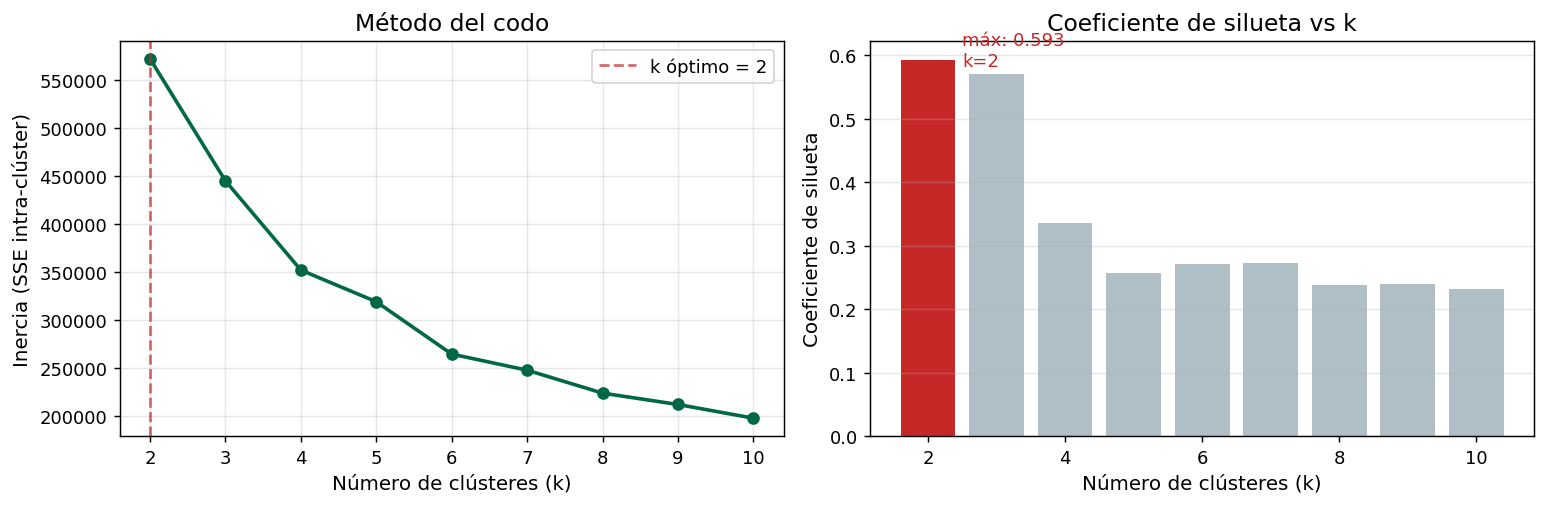

In [4]:
# ── Figura: codo + silueta ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Codo
axes[0].plot(ks, inertias, marker='o', color=COLOR_SEGURO, linewidth=2)
axes[0].axvline(k_optimo, color=COLOR_RIESGO, linestyle='--', alpha=0.7,
                label=f'k óptimo = {k_optimo}')
axes[0].set_xlabel('Número de clústeres (k)')
axes[0].set_ylabel('Inercia (SSE intra-clúster)')
axes[0].set_title('Método del codo')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silueta
colores_bar = [COLOR_RIESGO if k == k_optimo else COLOR_NEUTRO for k in ks]
axes[1].bar(ks, silhouettes, color=colores_bar)
axes[1].set_xlabel('Número de clústeres (k)')
axes[1].set_ylabel('Coeficiente de silueta')
axes[1].set_title('Coeficiente de silueta vs k')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].annotate(f'máx: {score_optimo:.3f}\nk={k_optimo}',
                 xy=(k_optimo, score_optimo),
                 xytext=(k_optimo + 0.5, score_optimo - 0.01),
                 fontsize=10, color=COLOR_RIESGO)

plt.tight_layout()
plt.show()

In [5]:
calidad = 'excelente' if score_optimo > 0.5 else 'aceptable' if score_optimo > 0.3 else 'débil'

display(Markdown(f"""
### Resultado de la búsqueda de k

| Parámetro | Valor |
|---|---|
| K evaluados | {K_MIN} a {K_MAX} |
| **K óptimo seleccionado** | **{k_optimo}** |
| Coeficiente de silueta en k={k_optimo} | {score_optimo:.3f} ({calidad}) |
| Muestra usada para la búsqueda | {len(X_muestra):,} registros |

El coeficiente de silueta para k={k_optimo} es **{score_optimo:.3f}**, lo que indica
separación **{calidad}** entre los grupos. Un valor > 0.3 es suficiente para análisis
exploratorio en datos clínicos; valores > 0.5 indican clústeres bien definidos.
"""))


### Resultado de la búsqueda de k

| Parámetro | Valor |
|---|---|
| K evaluados | 2 a 10 |
| **K óptimo seleccionado** | **2** |
| Coeficiente de silueta en k=2 | 0.593 (excelente) |
| Muestra usada para la búsqueda | 5,000 registros |

El coeficiente de silueta para k=2 es **0.593**, lo que indica
separación **excelente** entre los grupos. Un valor > 0.3 es suficiente para análisis
exploratorio en datos clínicos; valores > 0.5 indican clústeres bien definidos.


---

## Bloque 2 — Ajuste del modelo final

Con k={k_optimo} seleccionado, se ajusta el modelo K-Means final sobre el dataset completo.
Cada paciente queda asignado a uno de los {k_optimo} fenotipos.

In [6]:
# ── Ajuste del modelo final sobre todos los datos ─────────────────────────────
fenotipador = FenotipadoKMeans(n_clusters_max=K_MAX, random_state=SEMILLA)
etiquetas   = fenotipador.ajustar(X, n_clusters=k_optimo).predecir_fenotipo(X)
score_final = fenotipador.calcular_silhouette(X)

nombres_fenotipos = [f'Fenotipo {chr(65 + i)}' for i in range(k_optimo)]
conteos = pd.Series(etiquetas).value_counts().sort_index()
conteos.index = nombres_fenotipos

df_conteos = pd.DataFrame({
    'Fenotipo': nombres_fenotipos,
    'Registros': conteos.values,
    'Porcentaje (%)': (conteos.values / len(etiquetas) * 100).round(1),
})

display(Markdown(f"""
### Modelo ajustado con k={k_optimo} clústeres

**Coeficiente de silueta (dataset completo):** {score_final:.3f}  
**Total de pacientes asignados:** {len(etiquetas):,}
"""))
display(df_conteos.style.hide(axis='index')
        .bar(subset=['Porcentaje (%)'], color=COLOR_NEUTRO)
        .set_caption('Distribución de pacientes por fenotipo'))


### Modelo ajustado con k=2 clústeres

**Coeficiente de silueta (dataset completo):** 0.589  
**Total de pacientes asignados:** 50,000


Fenotipo,Registros,Porcentaje (%)
Fenotipo A,6275,12.600000
Fenotipo B,43725,87.400000


---

## Bloque 3 — Perfiles de clústeres

Los centroides de cada clúster representan el "paciente promedio" de cada fenotipo.
Los valores se normalizan (0 = mínimo, 1 = máximo dentro de cada variable) para
facilitar la comparación entre variables con distintas escalas.

In [7]:
# ── Centroides normalizados ────────────────────────────────────────────────────
centroides = pd.DataFrame(
    fenotipador._model.cluster_centers_,
    columns=list(COLUMNAS_CDC),
    index=nombres_fenotipos,
)

centroides_norm = centroides.apply(
    lambda c: (c - c.min()) / (c.max() - c.min() + 1e-9), axis=0
)

display(Markdown('### Perfiles normalizados por fenotipo'))
display(
    centroides_norm.style
    .background_gradient(cmap='RdYlGn', axis=0)
    .format('{:.2f}')
    .set_caption('Verde = valor alto relativo · Rojo = valor bajo relativo (por columna)')
)

### Perfiles normalizados por fenotipo

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
Fenotipo A,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00
Fenotipo B,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,1.00


In [8]:
# ── Narrativa automática: top variables por fenotipo ──────────────────────────
bloques = []
for nombre in nombres_fenotipos:
    top = centroides.loc[nombre].nlargest(4).index.tolist()
    bottom = centroides.loc[nombre].nsmallest(3).index.tolist()
    bloques.append(
        f"- **{nombre}** — más elevado en: *{', '.join(top)}*; "
        f"más bajo en: *{', '.join(bottom)}*."
    )

display(Markdown(
    '### Descripción por fenotipo (variables más discriminantes)\n\n'
    + '\n'.join(bloques)
))

### Descripción por fenotipo (variables más discriminantes)

- **Fenotipo A** — más elevado en: *BMI, PhysHlth, MentHlth, Age*; más bajo en: *HvyAlcoholConsump, Stroke, NoDocbcCost*.
- **Fenotipo B** — más elevado en: *BMI, Age, Income, Education*; más bajo en: *Stroke, HvyAlcoholConsump, NoDocbcCost*.

---

## Bloque 4 — Prevalencia de diabetes tipo 2 por fenotipo

Se verifica si los fenotipos encontrados de forma **no supervisada** coinciden con
diferencias reales en la prevalencia de diabetes. Esto no forma parte del entrenamiento,
sino de la validación clínica del clustering.

In [9]:
from scipy import stats

# ── Prevalencia por fenotipo ───────────────────────────────────────────────────
df_analisis = X.copy()
df_analisis['fenotipo'] = [nombres_fenotipos[e] for e in etiquetas]
df_analisis['diabetes'] = y.values

prevalencia = (
    df_analisis.groupby('fenotipo')['diabetes']
    .agg(n='count', tasa='mean')
    .assign(tasa_pct=lambda d: d['tasa'] * 100)
    .sort_values('tasa', ascending=False)
)

fenotipo_alto = prevalencia['tasa'].idxmax()
fenotipo_bajo = prevalencia['tasa'].idxmin()
diferencia    = prevalencia['tasa_pct'].max() - prevalencia['tasa_pct'].min()

# Chi-cuadrado: ¿la distribución de diabetes es significativamente distinta entre fenotipos?
tabla_contingencia = pd.crosstab(df_analisis['fenotipo'], df_analisis['diabetes'])
chi2, p_value, _, _ = stats.chi2_contingency(tabla_contingencia)

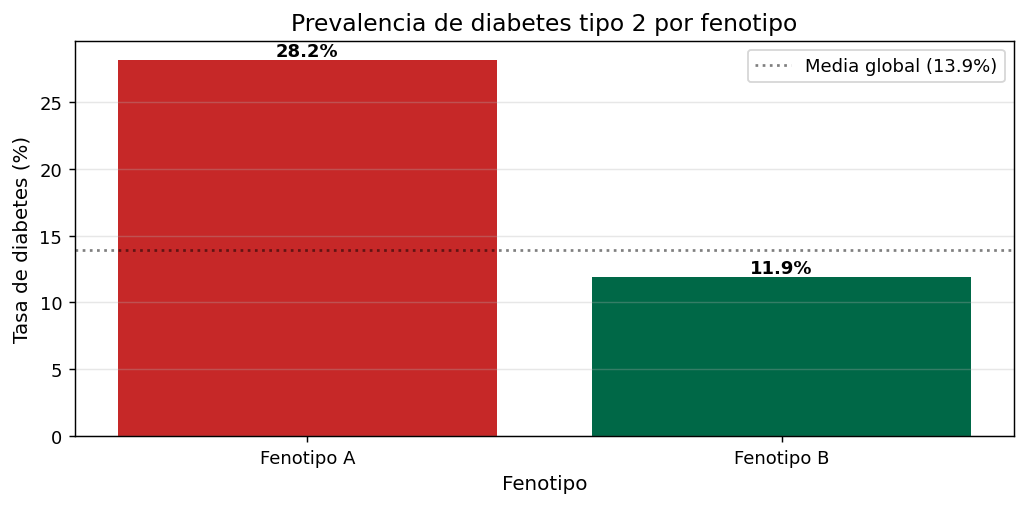

In [10]:
# ── Figura: prevalencia por fenotipo ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

colores = [
    COLOR_RIESGO if f == fenotipo_alto
    else COLOR_SEGURO if f == fenotipo_bajo
    else COLOR_ALERTA
    for f in prevalencia.index
]

ax.bar(prevalencia.index, prevalencia['tasa_pct'], color=colores)
for i, (idx, row) in enumerate(prevalencia.iterrows()):
    ax.text(i, row['tasa_pct'] + 0.3, f"{row['tasa_pct']:.1f}%",
            ha='center', fontsize=10, fontweight='bold')

ax.axhline(y.mean() * 100, color='black', linestyle=':', alpha=0.5,
           label=f'Media global ({y.mean()*100:.1f}%)')
ax.set_xlabel('Fenotipo')
ax.set_ylabel('Tasa de diabetes (%)')
ax.set_title('Prevalencia de diabetes tipo 2 por fenotipo')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [11]:
significancia = 'estadísticamente significativa (p < 0.001)' if p_value < 0.001 \
    else f'estadísticamente significativa (p = {p_value:.4f})' if p_value < 0.05 \
    else f'no significativa (p = {p_value:.3f})'

display(Markdown(f"""
### Prevalencia de diabetes por fenotipo

| Fenotipo | Pacientes | Tasa de diabetes |
|---|---|---|
""" + '\n'.join(
    f"| {idx} | {int(row['n']):,} | {row['tasa_pct']:.1f}% |"
    for idx, row in prevalencia.iterrows()
) + f"""

**Hallazgos principales:**

- **{fenotipo_alto}** concentra la mayor prevalencia de diabetes: \
**{prevalencia.loc[fenotipo_alto, 'tasa_pct']:.1f}%**
  ({int(prevalencia.loc[fenotipo_alto, 'n']):,} pacientes).
- **{fenotipo_bajo}** tiene la menor prevalencia:
  **{prevalencia.loc[fenotipo_bajo, 'tasa_pct']:.1f}%**.
- La diferencia entre extremos es **{diferencia:.1f} puntos porcentuales**.
- La prueba χ² entre fenotipos y diabetes es {significancia}
  (χ²={chi2:.1f}), lo que indica que los fenotipos capturan
  {'diferencias clínicas reales' if p_value < 0.05 else 'diferencias no significativas'}.
"""))


### Prevalencia de diabetes por fenotipo

| Fenotipo | Pacientes | Tasa de diabetes |
|---|---|---|
| Fenotipo A | 6,275 | 28.2% |
| Fenotipo B | 43,725 | 11.9% |

**Hallazgos principales:**

- **Fenotipo A** concentra la mayor prevalencia de diabetes: **28.2%**
  (6,275 pacientes).
- **Fenotipo B** tiene la menor prevalencia:
  **11.9%**.
- La diferencia entre extremos es **16.3 puntos porcentuales**.
- La prueba χ² entre fenotipos y diabetes es estadísticamente significativa (p < 0.001)
  (χ²=1209.4), lo que indica que los fenotipos capturan
  diferencias clínicas reales.


---

## Bloque 5 — Síntesis y exportación

Se resume el análisis en un JSON estructurado para uso posterior
(dashboard, reporte final, comparativa con papers).

In [12]:
# ── Construir y exportar JSON de hallazgos ────────────────────────────────────
hallazgos = {
    'metadata': {
        'fecha': datetime.now(tz=timezone.utc).isoformat(),
        'n_registros': int(len(df_analisis)),
        'k_optimo': int(k_optimo),
        'silhouette_score': round(float(score_final), 4),
        'muestra_busqueda_k': int(len(X_muestra)),
        'chi2': round(float(chi2), 2),
        'p_value_chi2': round(float(p_value), 6),
    },
    'fenotipos': [
        {
            'nombre': nombre,
            'n': int(prevalencia.loc[nombre, 'n']),
            'tasa_diabetes': round(float(prevalencia.loc[nombre, 'tasa']), 4),
            'tasa_diabetes_pct': round(float(prevalencia.loc[nombre, 'tasa_pct']), 1),
            'top_4_variables': centroides.loc[nombre].nlargest(4).index.tolist(),
        }
        for nombre in nombres_fenotipos
    ],
}

ruta_json = REPORTES_DIR / 'hallazgos_fenotipado.json'
ruta_json.write_text(json.dumps(hallazgos, indent=2, ensure_ascii=False), encoding='utf-8')

display(Markdown(f"""
### Síntesis del análisis de fenotipos

| Métrica | Valor |
|---|---|
| Número de fenotipos (k óptimo) | {k_optimo} |
| Coeficiente de silueta (dataset completo) | {score_final:.3f} |
| Fenotipo de mayor riesgo | {fenotipo_alto} ({prevalencia.loc[fenotipo_alto,'tasa_pct']:.1f}% diabetes) |
| Fenotipo de menor riesgo | {fenotipo_bajo} ({prevalencia.loc[fenotipo_bajo,'tasa_pct']:.1f}% diabetes) |
| Diferencia entre extremos | {diferencia:.1f} pp |
| Significancia clínica (χ²) | {significancia} |
| Registros analizados | {len(df_analisis):,} |

✅ Exportado: `{ruta_json.as_posix()}`

---
*Notebook ejecutado el {datetime.now(tz=timezone.utc).strftime('%Y-%m-%d')}*
"""))


### Síntesis del análisis de fenotipos

| Métrica | Valor |
|---|---|
| Número de fenotipos (k óptimo) | 2 |
| Coeficiente de silueta (dataset completo) | 0.589 |
| Fenotipo de mayor riesgo | Fenotipo A (28.2% diabetes) |
| Fenotipo de menor riesgo | Fenotipo B (11.9% diabetes) |
| Diferencia entre extremos | 16.3 pp |
| Significancia clínica (χ²) | estadísticamente significativa (p < 0.001) |
| Registros analizados | 50,000 |

✅ Exportado: `/workspaces/Diasgnostico-pred/reportes/hallazgos_fenotipado.json`

---
*Notebook ejecutado el 2026-05-18*
